# Notebook 7 — Retrieval Error Analysis

This notebook analyzes failure cases from the visual product retrieval system.

The analysis focuses on:

- identifying poorly retrieved queries,
- inspecting their retrieved products,
- comparing successful and failed retrievals,
- identifying common failure patterns,
- analyzing category-level weaknesses,
- and documenting limitations of the current approach.

The purpose is not to improve the model yet, but to understand where and why
the current pretrained CNN embedding approach fails.

The relevance criterion used throughout the project is `articleType`.
Therefore, an "incorrect" retrieval means that the retrieved product has a
different `articleType` from the query product.

This is a proxy evaluation criterion rather than human-annotated visual
similarity. Consequently, some apparently incorrect retrievals may still be
visually similar to a human observer.

## 1. Imports and Configuration

We load the metadata and model-comparison results generated in the previous
notebooks.

Notebook 7 does not regenerate the CNN embeddings. It reuses the saved
evaluation outputs wherever possible.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display

In [2]:
PROJECT_ROOT = Path.cwd().parent

if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = Path.cwd()

RESULTS_DIR = PROJECT_ROOT / "results"
METADATA_PATH = PROJECT_ROOT / "data" / "processed" / "product_metadata.csv"
IMAGE_ROOT = PROJECT_ROOT / "data" / "fashion-product-images-small" / "images"

print("Project root:", PROJECT_ROOT)
print("Results directory exists:", RESULTS_DIR.exists())
print("Metadata exists:", METADATA_PATH.exists())
print("Image directory exists:", IMAGE_ROOT.exists())

Project root: d:\Projects\VisualProductSearch
Results directory exists: True
Metadata exists: True
Image directory exists: True


In [3]:
metadata = pd.read_csv(METADATA_PATH)

comparison_path = RESULTS_DIR / "model_comparison_query_results.csv"
summary_path = RESULTS_DIR / "model_comparison_summary.csv"
category_path = RESULTS_DIR / "model_comparison_category_metrics.csv"

comparison_df = pd.read_csv(comparison_path)
model_summary = pd.read_csv(summary_path, index_col=0)
category_comparison = pd.read_csv(category_path)

print("Metadata:", metadata.shape)
print("Query-level comparison:", comparison_df.shape)
print("Model summary:", model_summary.shape)
print("Category comparison:", category_comparison.shape)

Metadata: (44441, 11)
Query-level comparison: (3000, 9)
Model summary: (3, 10)
Category comparison: (84, 9)


## 2. Select the Model for Detailed Analysis

The model comparison from Notebook 6 provides the overall retrieval metrics.

For detailed error analysis, we select the model with the highest `map_at_10`.

mAP@10 is used as the primary selection criterion because it considers both
the number and ranking of relevant products among the retrieved results.

In [4]:
best_model = model_summary["map_at_10"].idxmax()

print("Best model:", best_model)
print("mAP@10:", model_summary.loc[best_model, "map_at_10"])

Best model: EfficientNet-B0
mAP@10: 0.7156804761904761


In [5]:
best_model_df = comparison_df[
    comparison_df["model"] == best_model
].copy()

best_model_df = best_model_df.reset_index(drop=True)

print("Queries analyzed:", len(best_model_df))
display(best_model_df.head())

Queries analyzed: 1000


,model,query_product_id,article_type,recall@5,precision@5,ap@5,recall@10,precision@10,ap@10
0,EfficientNet-B0,28032,Briefs,0.005896,1.0,1.00,0.011792,1.0,1.000000
1,EfficientNet-B0,35322,Earrings,0.012019,1.0,1.00,0.021635,0.9,0.878889
2,EfficientNet-B0,13284,Shorts,0.009158,1.0,1.00,0.018315,1.0,1.000000
3,EfficientNet-B0,26197,Perfume and Body Mist,0.003263,0.4,0.28,0.008157,0.5,0.288413
4,EfficientNet-B0,3391,Handbags,0.002844,1.0,1.00,0.005688,1.0,1.000000


## 3. Identify Poor Retrieval Queries

We rank queries by their retrieval quality.

A query with low `precision@10` retrieves few products belonging to the same
article type as the query.

Queries with low `ap@10` are especially useful for error analysis because
Average Precision also considers the ranking position of relevant products.

We therefore use `ap@10` as the primary measure for identifying difficult
queries.

In [6]:
poor_queries = best_model_df.sort_values(
    "ap@10",
    ascending=True
).copy()

display(
    poor_queries[
        [
            "query_product_id",
            "article_type",
            "precision@5",
            "precision@10",
            "ap@5",
            "ap@10"
        ]
    ].head(20)
)

,query_product_id,article_type,precision@5,precision@10,ap@5,ap@10
921,12770,Tops,0.0,0.0,0.0,0.0
935,57187,Tunics,0.0,0.0,0.0,0.0
852,32256,Tunics,0.0,0.0,0.0,0.0
34,47109,Casual Shoes,0.0,0.0,0.0,0.0
802,57065,Tops,0.0,0.0,0.0,0.0
813,3663,Sports Shoes,0.0,0.0,0.0,0.0
50,54977,Lounge Pants,0.0,0.0,0.0,0.0
541,19324,Sweatshirts,0.0,0.0,0.0,0.0
605,57796,Face Wash and Cleanser,0.0,0.0,0.0,0.0
519,19517,Sweaters,0.0,0.0,0.0,0.0


## 4. Quantify Retrieval Quality

Before inspecting individual images, we summarize how many queries fall into
different retrieval-quality groups.

This gives a high-level view of the failure rate before visual inspection.

In [7]:
quality_distribution = pd.Series({
    "Perfect@10": (best_model_df["precision@10"] == 1.0).sum(),
    "High (0.8-<1.0)": (
        (best_model_df["precision@10"] >= 0.8) &
        (best_model_df["precision@10"] < 1.0)
    ).sum(),
    "Medium (0.5-<0.8)": (
        (best_model_df["precision@10"] >= 0.5) &
        (best_model_df["precision@10"] < 0.8)
    ).sum(),
    "Low (0-<0.5)": (
        best_model_df["precision@10"] < 0.5
    ).sum()
})

display(quality_distribution.to_frame("query_count"))

,query_count
Perfect@10,460
High (0.8-<1.0),188
Medium (0.5-<0.8),174
Low (0-<0.5),178


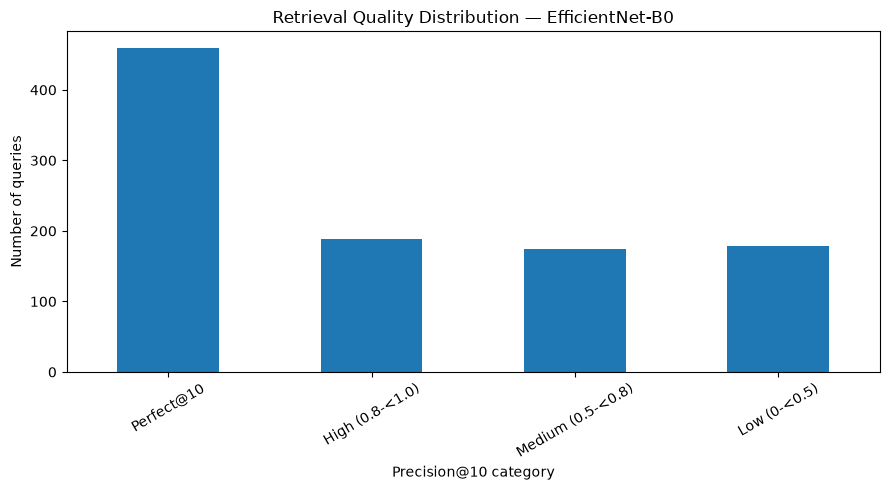

In [8]:
plt.figure(figsize=(9, 5))

quality_distribution.plot(
    kind="bar"
)

plt.title(f"Retrieval Quality Distribution — {best_model}")
plt.xlabel("Precision@10 category")
plt.ylabel("Number of queries")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 5. Analyze Category-Level Failures

Some product categories are inherently harder to distinguish than others.

We therefore inspect category-level performance for the selected model.

Only categories with at least 10 evaluated queries are considered to avoid
drawing conclusions from extremely small samples.

In [9]:
best_category_metrics = category_comparison[
    category_comparison["model"] == best_model
].copy()

best_category_metrics = best_category_metrics[
    best_category_metrics["queries"] >= 10
].copy()

best_category_metrics = best_category_metrics.sort_values(
    "map_at_10"
)

display(
    best_category_metrics[
        [
            "article_type",
            "queries",
            "precision_at_5",
            "precision_at_10",
            "map_at_5",
            "map_at_10"
        ]
    ].head(20)
)

,article_type,queries,precision_at_5,precision_at_10,map_at_5,map_at_10
7,Flats,12,0.416667,0.341667,0.341111,0.229395
5,Dresses,15,0.466667,0.426667,0.385556,0.319651
22,Tops,39,0.538462,0.497436,0.470427,0.394124
23,Track Pants,12,0.633333,0.525000,0.552500,0.430086
11,Heels,27,0.637037,0.548148,0.562963,0.444161
13,Kurtas,43,0.716279,0.693023,0.611008,0.570608
20,Sports Shoes,46,0.673913,0.680435,0.585652,0.572130
4,Casual Shoes,74,0.702703,0.689189,0.619730,0.579884
14,Perfume and Body Mist,15,0.786667,0.720000,0.722222,0.627540
15,Sandals,23,0.800000,0.704348,0.722029,0.627683


In [10]:
top_categories = best_category_metrics.sort_values(
    "map_at_10",
    ascending=False
).head(10)

bottom_categories = best_category_metrics.sort_values(
    "map_at_10",
    ascending=True
).head(10)

print("Top 10 categories:")
display(
    top_categories[
        ["article_type", "queries", "precision_at_10", "map_at_10"]
    ]
)

print("\nBottom 10 categories:")
display(
    bottom_categories[
        ["article_type", "queries", "precision_at_10", "map_at_10"]
    ]
)

Top 10 categories:


,article_type,queries,precision_at_10,map_at_10
2,Bra,11,1.000000,1.000000
21,Sunglasses,19,0.994737,0.992968
19,Socks,13,0.992308,0.991538
1,Belts,19,0.984211,0.972297
27,Watches,58,0.977586,0.969745
0,Backpacks,16,0.975000,0.953085
17,Shirts,79,0.948101,0.934411
3,Briefs,19,0.942105,0.929657
6,Earrings,13,0.907692,0.884332
25,Tshirts,141,0.876596,0.844839



Bottom 10 categories:


,article_type,queries,precision_at_10,map_at_10
7,Flats,12,0.341667,0.229395
5,Dresses,15,0.426667,0.319651
22,Tops,39,0.497436,0.394124
23,Track Pants,12,0.525000,0.430086
11,Heels,27,0.548148,0.444161
13,Kurtas,43,0.693023,0.570608
20,Sports Shoes,46,0.680435,0.572130
4,Casual Shoes,74,0.689189,0.579884
14,Perfume and Body Mist,15,0.720000,0.627540
15,Sandals,23,0.704348,0.627683


## 6. Compare Best and Worst Categories

The weakest categories are particularly useful for understanding systematic
failure modes.

Low category-level performance may indicate that:

- visually similar categories are difficult to distinguish,
- the pretrained ImageNet representation does not capture the required
  product-specific details,
- background or presentation differences affect the embedding,
- or the `articleType` labels are too fine-grained for the current feature
  representation.

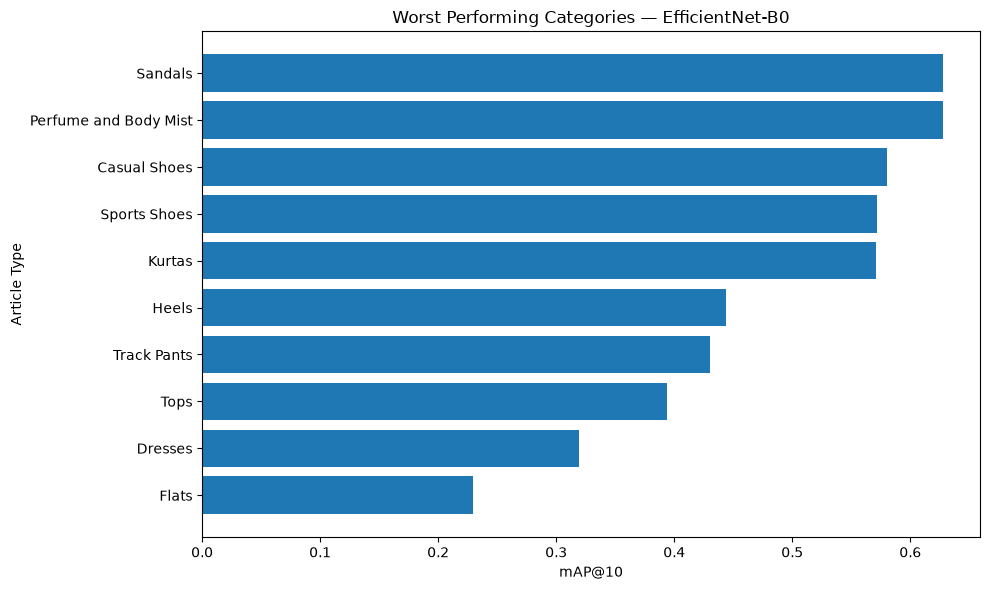

In [11]:
plt.figure(figsize=(10, 6))

plot_data = bottom_categories.sort_values("map_at_10")

plt.barh(
    plot_data["article_type"],
    plot_data["map_at_10"]
)

plt.xlabel("mAP@10")
plt.ylabel("Article Type")
plt.title(f"Worst Performing Categories — {best_model}")
plt.tight_layout()
plt.show()

## 7. Inspect Individual Failure Cases

We now inspect individual queries and their retrieved products.

For each selected query we will display:

1. the query product,
2. its article type,
3. the retrieved products,
4. their similarity scores,
5. and whether each retrieved product matches the query article type.

This is the most important part of the notebook because numerical metrics alone
cannot explain why retrieval fails.

In [12]:
def get_image_path(product_id):
    row = metadata.loc[
        metadata["id"] == product_id
    ]

    if row.empty:
        return None

    return PROJECT_ROOT / row.iloc[0]["image_path"]


def get_product_info(product_id):
    row = metadata.loc[
        metadata["id"] == product_id
    ]

    if row.empty:
        return None

    return row.iloc[0]

## 8. Load Retrieval Results for Individual Queries

Notebook 6 stores the evaluation metrics but not the full retrieved-product
lists.

For detailed visual inspection, we therefore regenerate retrieval for selected
queries using the saved embeddings and FAISS index corresponding to the best
model.

Only a small number of queries are inspected, so this does not require
regenerating the full catalog embeddings.

In [13]:
import faiss

EMBEDDINGS_DIR = PROJECT_ROOT / "embeddings"

embedding_files = {
    "ResNet-18": EMBEDDINGS_DIR / "resnet18_embeddings.npy",
    "ResNet-50": EMBEDDINGS_DIR / "resnet50_embeddings.npy",
    "EfficientNet-B0": EMBEDDINGS_DIR / "efficientnet_b0_embeddings.npy",
}

index_files = {
    "ResNet-18": EMBEDDINGS_DIR / "resnet18_faiss.index",
    "ResNet-50": EMBEDDINGS_DIR / "resnet50_faiss.index",
    "EfficientNet-B0": EMBEDDINGS_DIR / "efficientnet_b0_faiss.index",
}

print("Best model:", best_model)
print("Expected embedding file:", embedding_files[best_model])
print("Expected index file:", index_files[best_model])

Best model: EfficientNet-B0
Expected embedding file: d:\Projects\VisualProductSearch\embeddings\efficientnet_b0_embeddings.npy
Expected index file: d:\Projects\VisualProductSearch\embeddings\efficientnet_b0_faiss.index


## 9. Load the Selected Model's Embeddings and FAISS Index

The selected model from the previous analysis is EfficientNet-B0.

We load its catalog embeddings and FAISS index so that individual retrieval
results can be reconstructed for visual inspection.

The loaded embeddings must contain exactly the same products and ordering as
the processed metadata used during evaluation.

In [14]:
# Check which embedding/index files actually exist

print("Files in embeddings directory:")

for file in sorted(EMBEDDINGS_DIR.iterdir()):
    print(" -", file.name)

Files in embeddings directory:
 - embedding_product_ids.npy
 - product_embeddings.npy
 - product_embeddings_faiss.index


## 10. Recreate the Best Model for Error Analysis

Notebook 6 identified EfficientNet-B0 as the best-performing model according
to mAP@10.

The original embedding directory contains the ResNet-50 catalog embeddings,
but model-specific EfficientNet-B0 embeddings were not persisted.

Therefore, EfficientNet-B0 embeddings are regenerated here using the same:

- ImageNet-pretrained weights
- image preprocessing
- input resolution
- batch size
- catalog
- feature extraction configuration

used during model comparison.

Only EfficientNet-B0 is regenerated because it is the selected model for
detailed error analysis.

In [16]:
import torch
import torch.nn as nn

from torchvision import models, transforms
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

d:\Projects\VisualProductSearch\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 2050


In [18]:
image_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [19]:
class ProductImageDataset(torch.utils.data.Dataset):

    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image_path = PROJECT_ROOT / row["image_path"]

        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)

        product_id = int(row["id"])

        return image, product_id

In [20]:
comparison_dataset = ProductImageDataset(
    metadata,
    image_transform
)

comparison_loader = DataLoader(
    comparison_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Products:", len(comparison_dataset))

Products: 44441


## 11. Load EfficientNet-B0 Feature Extractor

The classification layer is removed so that the network outputs its
1280-dimensional feature representation.

These embeddings are used only for retrieval and error analysis; no fine-tuning
is performed.

In [21]:
efficientnet_weights = models.EfficientNet_B0_Weights.DEFAULT

efficientnet = models.efficientnet_b0(
    weights=efficientnet_weights
)

efficientnet.classifier[1] = nn.Identity()

efficientnet = efficientnet.to(device)
efficientnet.eval()

for parameter in efficientnet.parameters():
    parameter.requires_grad = False

print("EfficientNet-B0 ready")

EfficientNet-B0 ready


In [22]:
def generate_embeddings(model, data_loader, device):

    model.eval()

    all_embeddings = []
    all_ids = []

    if device.type == "cuda":
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    with torch.no_grad():

        for images, product_ids in tqdm(
            data_loader,
            desc="Generating EfficientNet-B0 embeddings"
        ):

            images = images.to(
                device,
                non_blocking=True
            )

            features = model(images)

            features = (
                features
                .cpu()
                .numpy()
                .astype(np.float32)
            )

            all_embeddings.append(features)
            all_ids.append(product_ids.numpy())

    if device.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start_time

    embeddings = np.vstack(all_embeddings)
    product_ids = np.concatenate(all_ids)

    return embeddings, product_ids, elapsed

In [24]:
import time
efficientnet_embeddings, efficientnet_ids, extraction_time = (
    generate_embeddings(
        efficientnet,
        comparison_loader,
        device
    )
)

print("Embedding shape:", efficientnet_embeddings.shape)
print("Extraction time:", f"{extraction_time:.2f} seconds")

Generating EfficientNet-B0 embeddings: 100%|██████████| 1389/1389 [07:06<00:00,  3.26it/s]


Embedding shape: (44441, 1280)
Extraction time: 426.04 seconds


## 12. Validate Embedding Alignment

The embedding row order must match the processed metadata exactly.

This is critical because FAISS returns row indices rather than product IDs.
If the ordering is incorrect, retrieved products would be mapped to the wrong
metadata records.

In [25]:
expected_ids = metadata["id"].to_numpy()

assert efficientnet_embeddings.shape[0] == len(metadata)

assert np.array_equal(
    efficientnet_ids,
    expected_ids
)

assert efficientnet_embeddings.dtype == np.float32

print("✓ EfficientNet-B0 embeddings aligned with metadata")
print("✓ Product count:", len(efficientnet_embeddings))
print("✓ Embedding dimension:", efficientnet_embeddings.shape[1])

✓ EfficientNet-B0 embeddings aligned with metadata
✓ Product count: 44441
✓ Embedding dimension: 1280


## 13. Build the FAISS Index

The embeddings are L2-normalized so that inner product is equivalent to
cosine similarity.

An exact `IndexFlatIP` index is used, matching the retrieval methodology from
Notebook 6.

In [26]:
normalized_efficientnet = efficientnet_embeddings.copy()

faiss.normalize_L2(
    normalized_efficientnet
)

efficientnet_index = faiss.IndexFlatIP(
    normalized_efficientnet.shape[1]
)

efficientnet_index.add(
    normalized_efficientnet
)

print("FAISS vectors:", efficientnet_index.ntotal)
print("Embedding dimension:", efficientnet_index.d)

FAISS vectors: 44441
Embedding dimension: 1280


## 14. Retrieval Function for Error Analysis

For each query, the query itself is excluded from the retrieved results.

The remaining Top-10 products are then compared against the query's
`articleType`.

A retrieval is marked as relevant when the retrieved product has the same
`articleType` as the query.

In [27]:
id_to_article_type = (
    metadata
    .set_index("id")["articleType"]
    .to_dict()
)


def retrieve_error_analysis(query_index, k=10):

    query_vector = normalized_efficientnet[
        query_index:query_index + 1
    ].copy()

    faiss.normalize_L2(query_vector)

    scores, indices = efficientnet_index.search(
        query_vector,
        k + 1
    )

    scores = scores[0]
    indices = indices[0]

    mask = indices != query_index

    indices = indices[mask][:k]
    scores = scores[mask][:k]

    query_product_id = int(
        metadata.iloc[query_index]["id"]
    )

    query_article_type = id_to_article_type[
        query_product_id
    ]

    retrieved_ids = [
        int(metadata.iloc[idx]["id"])
        for idx in indices
    ]

    retrieved_types = [
        id_to_article_type[product_id]
        for product_id in retrieved_ids
    ]

    return (
        query_product_id,
        query_article_type,
        retrieved_ids,
        retrieved_types,
        scores
    )

## 15. Reconstruct Query-Level Retrieval Results

We reconstruct the Top-10 retrievals for every evaluated query.

This allows us to identify the exact products responsible for successful and
failed retrievals.

In [29]:
# Recreate the same query set used in Notebook 6

RANDOM_SEED = 42
MAX_QUERIES = 1000
K_VALUES = [5, 10]

np.random.seed(RANDOM_SEED)

article_type_counts = metadata["articleType"].value_counts()

eligible_article_types = article_type_counts[
    article_type_counts >= 11
].index

eligible_metadata = metadata[
    metadata["articleType"].isin(eligible_article_types)
].copy()

query_count = min(
    MAX_QUERIES,
    len(eligible_metadata)
)

query_indices = np.random.choice(
    eligible_metadata.index.to_numpy(),
    size=query_count,
    replace=False
)

query_indices = np.sort(query_indices)

print("Eligible products:", len(eligible_metadata))
print("Queries:", len(query_indices))
print("Random seed:", RANDOM_SEED)

Eligible products: 44287
Queries: 1000
Random seed: 42


In [30]:
error_analysis_rows = []

for query_index in tqdm(
    query_indices,
    desc="Reconstructing retrieval results"
):

    (
        query_product_id,
        query_article_type,
        retrieved_ids,
        retrieved_types,
        scores
    ) = retrieve_error_analysis(
        query_index,
        k=10
    )

    for rank, (
        product_id,
        article_type,
        score
    ) in enumerate(
        zip(
            retrieved_ids,
            retrieved_types,
            scores
        ),
        start=1
    ):

        error_analysis_rows.append({
            "query_product_id": query_product_id,
            "query_article_type": query_article_type,
            "rank": rank,
            "retrieved_product_id": product_id,
            "retrieved_article_type": article_type,
            "similarity_score": float(score),
            "is_relevant": (
                article_type == query_article_type
            )
        })

error_analysis_df = pd.DataFrame(
    error_analysis_rows
)

print("Rows:", len(error_analysis_df))
display(error_analysis_df.head(20))

Reconstructing retrieval results: 100%|██████████| 1000/1000 [00:16<00:00, 59.53it/s]


Rows: 10000


,query_product_id,query_article_type,rank,retrieved_product_id,retrieved_article_type,similarity_score,is_relevant
0,28032,Briefs,1,25347,Briefs,0.762212,True
1,28032,Briefs,2,28030,Briefs,0.743704,True
2,28032,Briefs,3,28027,Briefs,0.741088,True
3,28032,Briefs,4,28028,Briefs,0.736682,True
4,28032,Briefs,5,57027,Briefs,0.717338,True
5,28032,Briefs,6,27953,Briefs,0.717197,True
6,28032,Briefs,7,25342,Briefs,0.716251,True
7,28032,Briefs,8,28025,Briefs,0.706968,True
8,28032,Briefs,9,28003,Briefs,0.706153,True
9,28032,Briefs,10,17853,Briefs,0.697278,True


## 16. Verify Retrieval Reconstruction

Every query should have exactly 10 retrieved products.

The query product itself must never appear in its retrieved results.

In [31]:
query_counts = (
    error_analysis_df
    .groupby("query_product_id")
    .size()
)

assert query_counts.eq(10).all()

assert not (
    error_analysis_df["query_product_id"]
    == error_analysis_df["retrieved_product_id"]
).any()

print("✓ Every query has exactly 10 retrieved products")
print("✓ Query products are excluded from retrieval results")

✓ Every query has exactly 10 retrieved products
✓ Query products are excluded from retrieval results


## 17. Compute Query-Level Error Statistics

For each query we calculate:

- number of relevant products in Top-10,
- Precision@10,
- average similarity of relevant results,
- average similarity of irrelevant results.

This helps determine whether failures are caused by completely unrelated
retrievals or by visually similar products belonging to a different
`articleType`.

In [32]:
query_error_stats = (
    error_analysis_df
    .groupby(
        [
            "query_product_id",
            "query_article_type"
        ]
    )
    .agg(
        relevant_in_top10=(
            "is_relevant",
            "sum"
        ),
        mean_similarity=(
            "similarity_score",
            "mean"
        ),
        relevant_similarity=(
            "similarity_score",
            lambda x: (
                x[
                    error_analysis_df.loc[
                        x.index,
                        "is_relevant"
                    ]
                ].mean()
            )
        ),
        irrelevant_similarity=(
            "similarity_score",
            lambda x: (
                x[
                    ~error_analysis_df.loc[
                        x.index,
                        "is_relevant"
                    ]
                ].mean()
            )
        )
    )
    .reset_index()
)

query_error_stats["precision_at_10"] = (
    query_error_stats["relevant_in_top10"] / 10
)

display(
    query_error_stats.head(20)
)

,query_product_id,query_article_type,relevant_in_top10,mean_similarity,relevant_similarity,irrelevant_similarity,precision_at_10
0,1544,Casual Shoes,7,0.683740,0.690382,0.668243,0.7
1,1599,Handbags,10,0.778913,0.778913,NaN,1.0
2,1798,Tshirts,4,0.897218,0.902062,0.893988,0.4
3,1844,Tshirts,10,0.867832,0.867832,NaN,1.0
4,1871,Tshirts,10,0.887768,0.887768,NaN,1.0
5,1938,Tshirts,10,0.898782,0.898782,NaN,1.0
6,1942,Tshirts,10,0.853864,0.853864,NaN,1.0
7,1951,Sports Shoes,3,0.641112,0.644192,0.639792,0.3
8,2035,Tshirts,10,0.922957,0.922957,NaN,1.0
9,2040,Tshirts,9,0.849020,0.849989,0.840302,0.9


## 18. Worst Individual Queries

The following queries contain the fewest relevant products in their Top-10
retrievals.

These are the primary candidates for visual inspection.

In [33]:
worst_queries = (
    query_error_stats
    .sort_values(
        [
            "relevant_in_top10",
            "mean_similarity"
        ],
        ascending=[
            True,
            True
        ]
    )
    .head(20)
)

display(worst_queries)

,query_product_id,query_article_type,relevant_in_top10,mean_similarity,relevant_similarity,irrelevant_similarity,precision_at_10
970,57796,Face Wash and Cleanser,0,0.571863,NaN,0.571863,0.0
69,5582,Sports Shoes,0,0.633067,NaN,0.633067,0.0
93,6477,Jackets,0,0.686030,NaN,0.686030,0.0
693,41796,Tunics,0,0.707403,NaN,0.707403,0.0
703,42583,Waistcoat,0,0.711925,NaN,0.711925,0.0
378,23446,Kurtis,0,0.738235,NaN,0.738235,0.0
564,33735,Clutches,0,0.752667,NaN,0.752667,0.0
191,12770,Tops,0,0.763533,NaN,0.763533,0.0
797,47109,Casual Shoes,0,0.774811,NaN,0.774811,0.0
953,57065,Tops,0,0.779034,NaN,0.779034,0.0


## 19. Visual Inspection of a Failure Case

We now display the query image alongside its Top-10 retrieved products.

The title of each retrieved image contains:

- rank,
- product ID,
- article type,
- cosine similarity,
- and whether the result matches the query article type.

This allows qualitative inspection of whether the model's failures are
actually visually unreasonable or whether the `articleType` proxy is too
strict.

In [34]:
def show_retrieval_case(query_product_id, k=10):

    query_row = metadata.loc[
        metadata["id"] == query_product_id
    ].iloc[0]

    query_article_type = query_row["articleType"]

    query_path = PROJECT_ROOT / query_row["image_path"]

    retrievals = error_analysis_df[
        error_analysis_df["query_product_id"]
        == query_product_id
    ].sort_values("rank").head(k)

    fig, axes = plt.subplots(
        2,
        6,
        figsize=(18, 7)
    )

    axes = axes.flatten()

    # Query image
    query_image = Image.open(
        query_path
    ).convert("RGB")

    axes[0].imshow(query_image)
    axes[0].set_title(
        f"QUERY\nID: {query_product_id}\n"
        f"Type: {query_article_type}"
    )
    axes[0].axis("off")

    # Retrieved images
    for i, (_, result) in enumerate(
        retrievals.iterrows(),
        start=1
    ):

        product_id = int(
            result["retrieved_product_id"]
        )

        product_row = metadata.loc[
            metadata["id"] == product_id
        ].iloc[0]

        image_path = (
            PROJECT_ROOT /
            product_row["image_path"]
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        axes[i].imshow(image)

        match = (
            "✓"
            if result["is_relevant"]
            else "✗"
        )

        axes[i].set_title(
            f"#{int(result['rank'])} {match}\n"
            f"ID: {product_id}\n"
            f"{result['retrieved_article_type']}\n"
            f"sim={result['similarity_score']:.3f}"
        )

        axes[i].axis("off")

    for ax in axes[len(retrievals) + 1:]:
        ax.axis("off")

    plt.suptitle(
        f"Retrieval Error Analysis — Query {query_product_id}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

Inspecting query: 57796


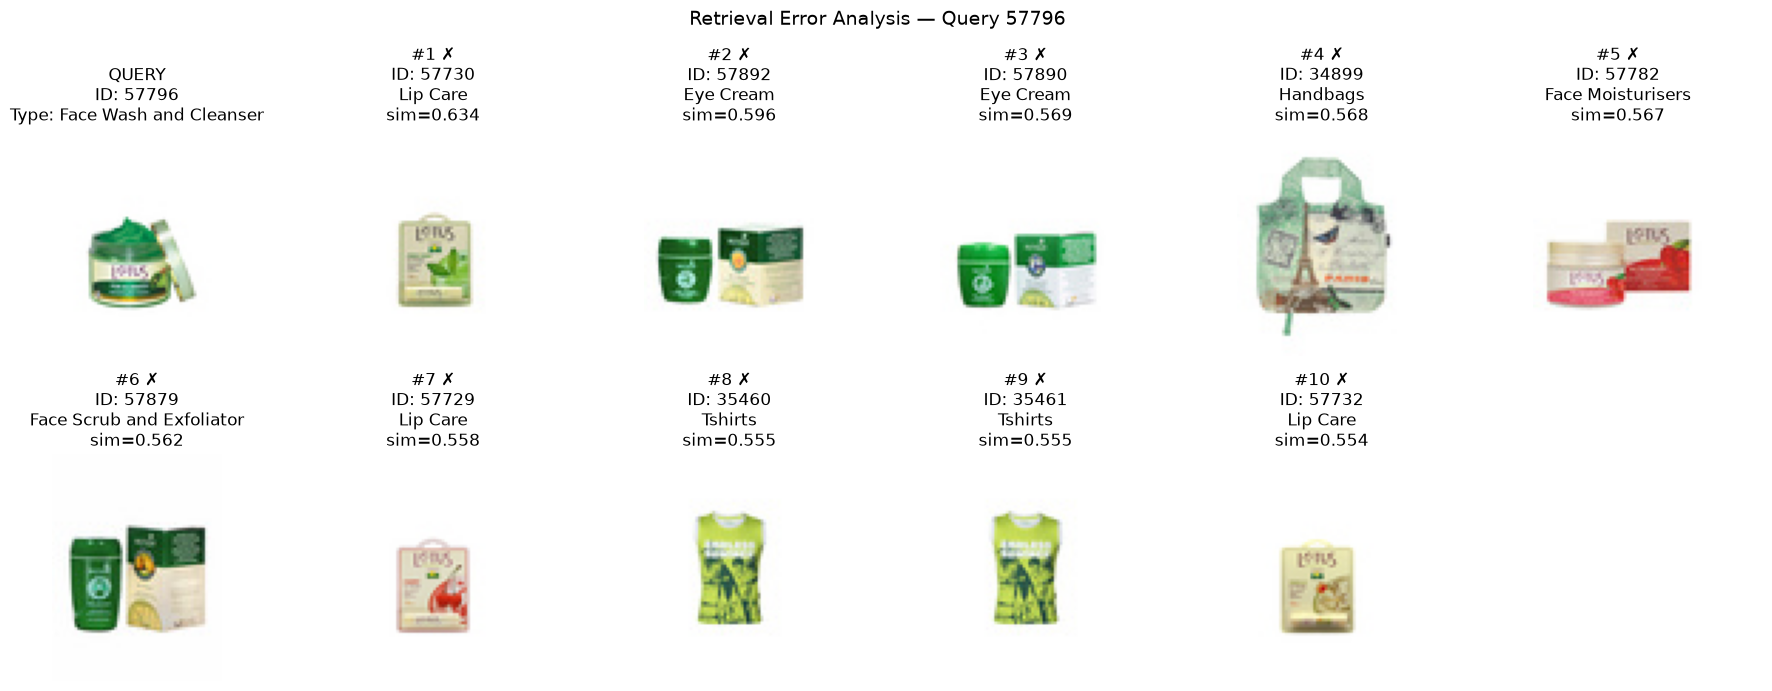

In [35]:
worst_query_id = int(
    worst_queries.iloc[0]["query_product_id"]
)

print("Inspecting query:", worst_query_id)

show_retrieval_case(
    worst_query_id,
    k=10
)

## 20. Inspect Multiple Failure Cases

The worst single query may be an unusual example.

We therefore inspect several of the lowest-performing queries to determine
whether a consistent failure pattern exists.


Query product ID: 57796


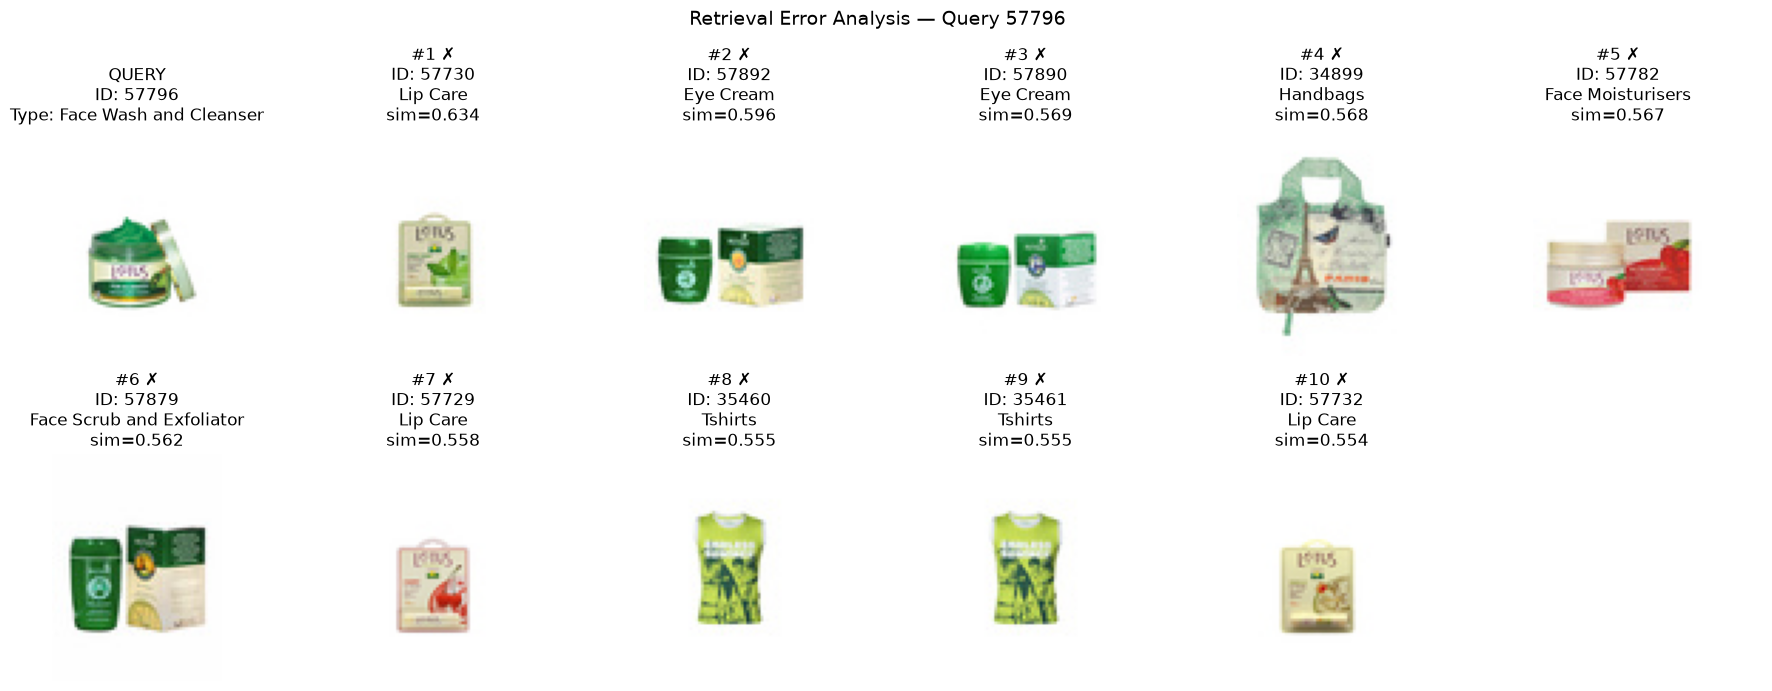


Query product ID: 5582


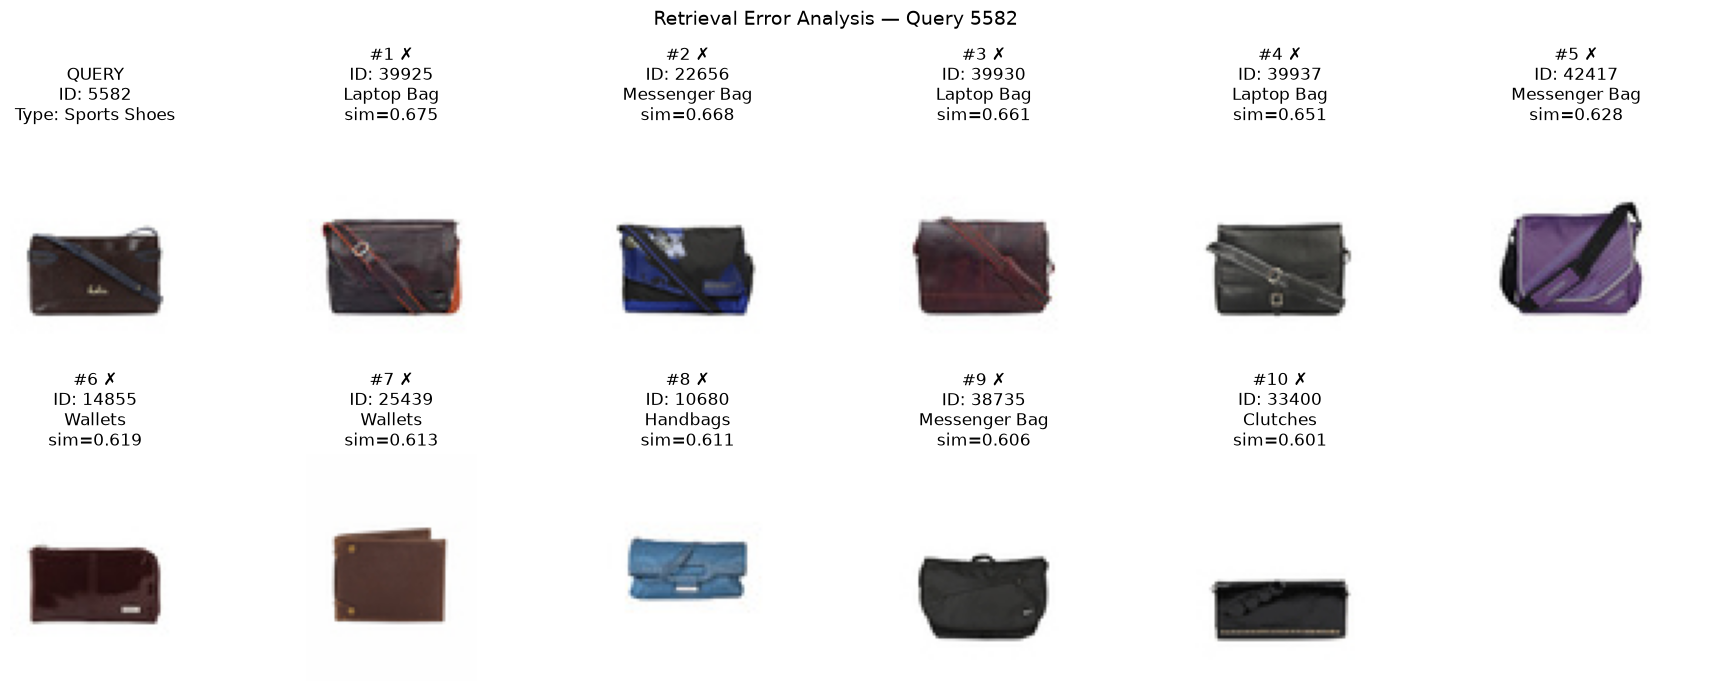


Query product ID: 6477


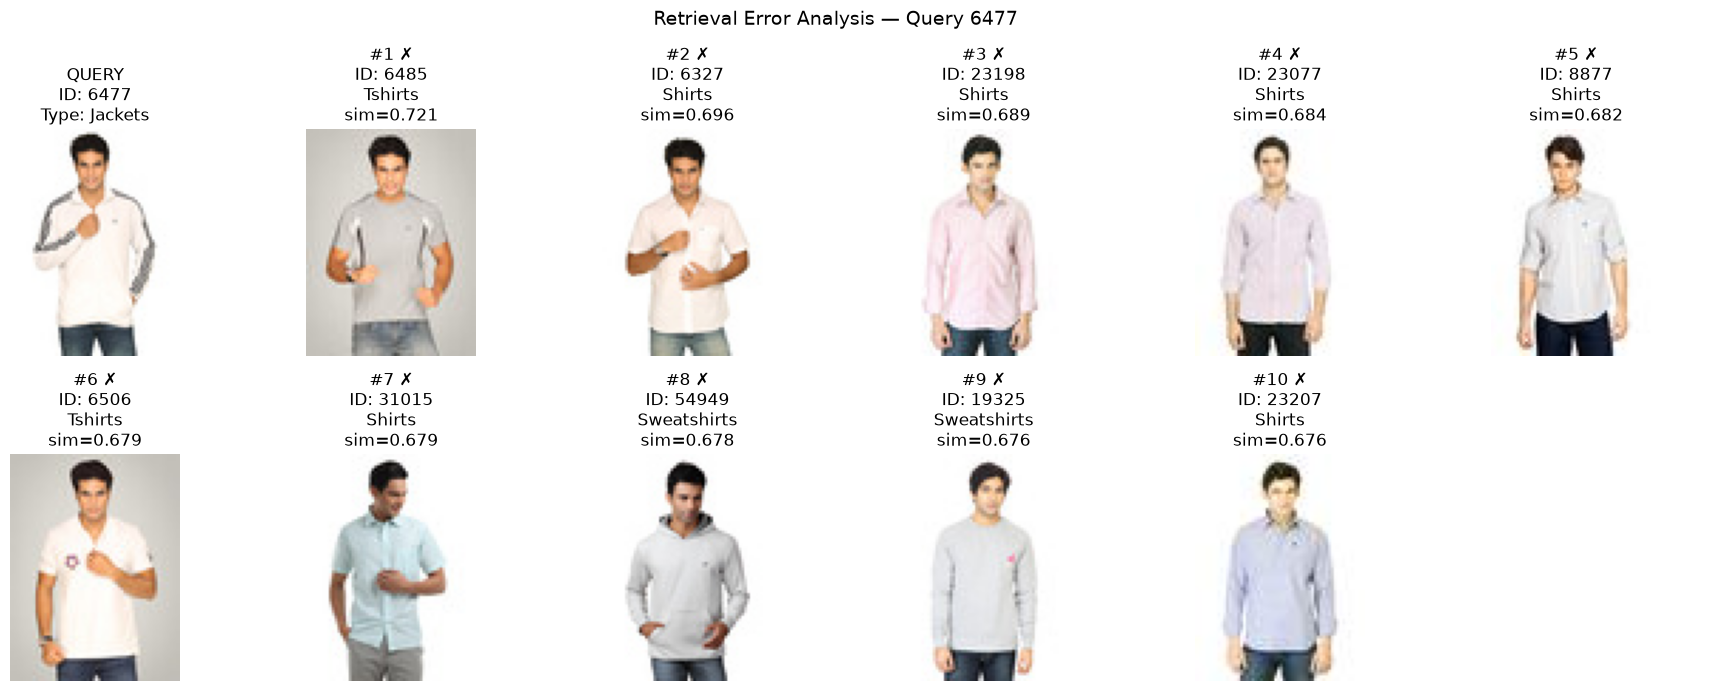


Query product ID: 41796


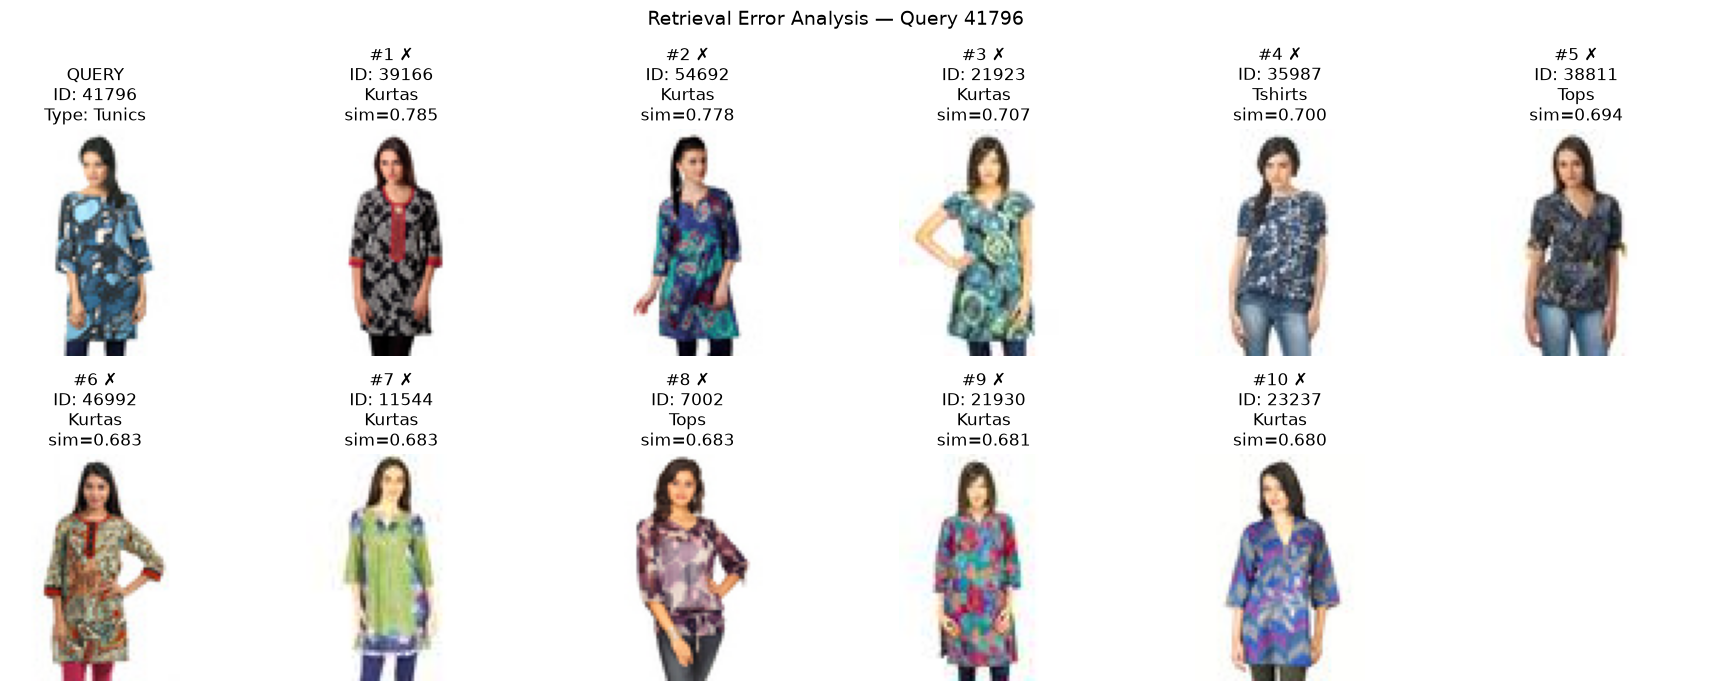


Query product ID: 42583


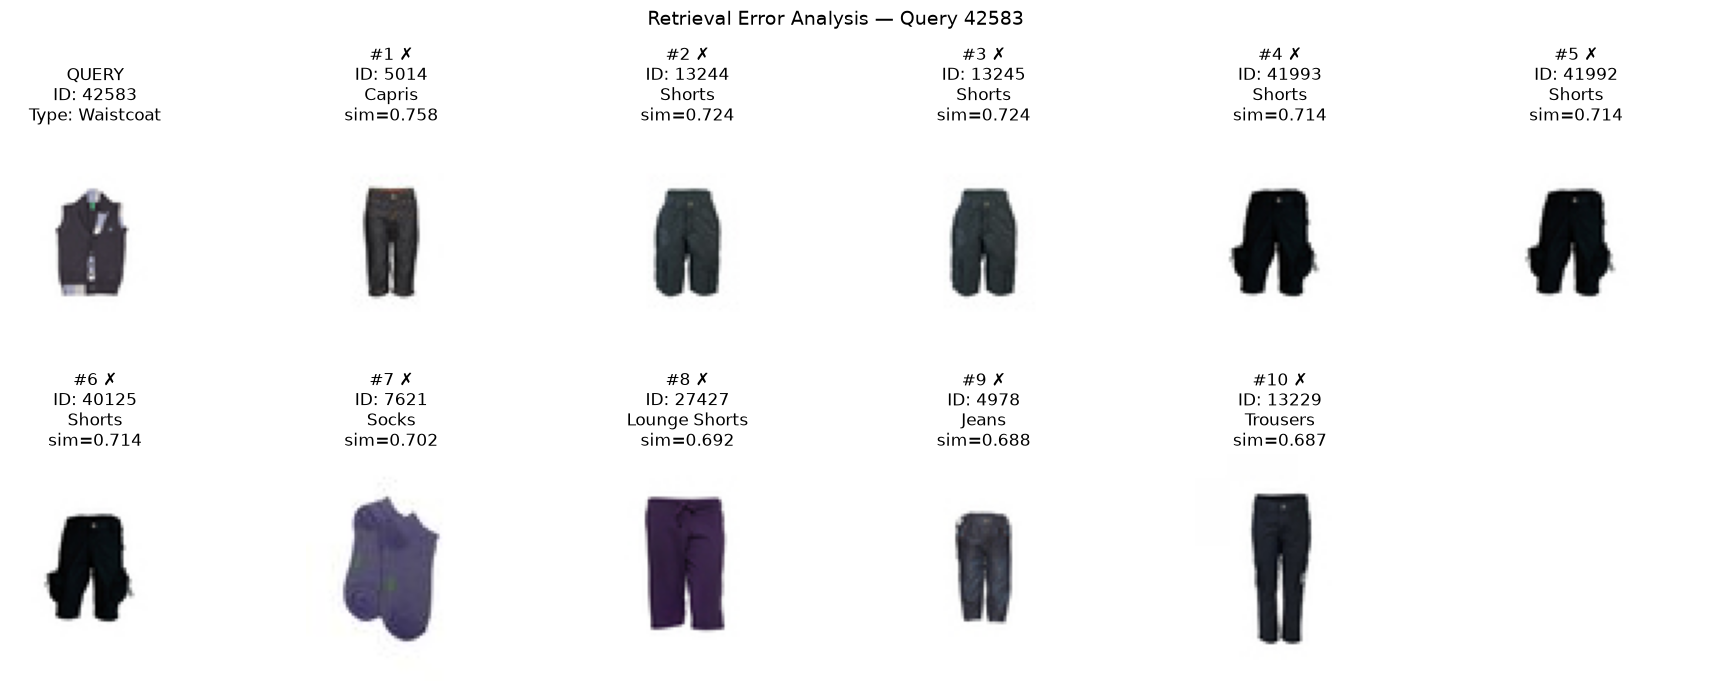

In [36]:
for query_id in worst_queries.head(5)["query_product_id"]:

    print(
        "\n" + "=" * 80
    )

    print(
        "Query product ID:",
        int(query_id)
    )

    show_retrieval_case(
        int(query_id),
        k=10
    )

## 21. Similarity Score Analysis

We compare the similarity distributions of relevant and irrelevant
retrievals.

A large overlap between the two distributions would indicate that the model
often assigns high visual similarity to products that belong to different
article types.

This would suggest that the pretrained embedding captures broad visual
appearance but does not reliably separate fine-grained product categories.

In [37]:
relevant_scores = error_analysis_df.loc[
    error_analysis_df["is_relevant"],
    "similarity_score"
]

irrelevant_scores = error_analysis_df.loc[
    ~error_analysis_df["is_relevant"],
    "similarity_score"
]

print(
    "Relevant retrievals:",
    len(relevant_scores)
)

print(
    "Irrelevant retrievals:",
    len(irrelevant_scores)
)

print(
    "\nMean relevant similarity:",
    relevant_scores.mean()
)

print(
    "Mean irrelevant similarity:",
    irrelevant_scores.mean()
)

Relevant retrievals: 7712
Irrelevant retrievals: 2288

Mean relevant similarity: 0.8147004490169499
Mean irrelevant similarity: 0.7741853966657724


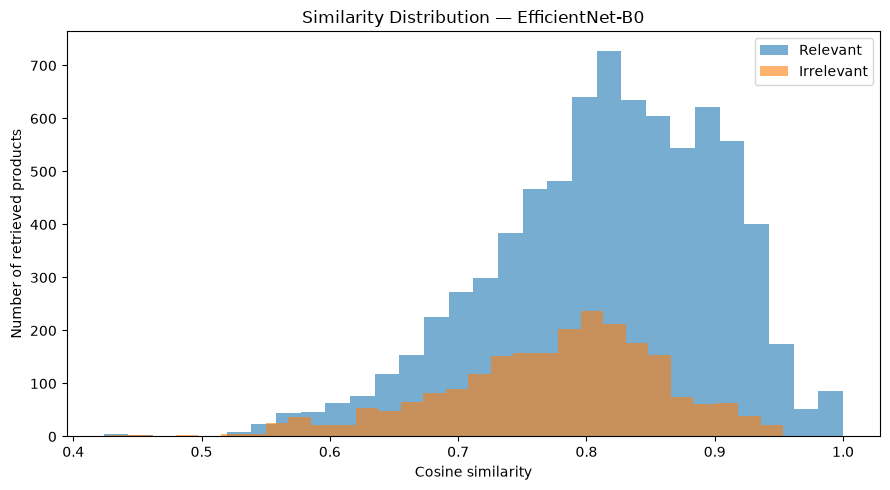

In [38]:
plt.figure(figsize=(9, 5))

plt.hist(
    relevant_scores,
    bins=30,
    alpha=0.6,
    label="Relevant"
)

plt.hist(
    irrelevant_scores,
    bins=30,
    alpha=0.6,
    label="Irrelevant"
)

plt.xlabel("Cosine similarity")
plt.ylabel("Number of retrieved products")
plt.title(
    f"Similarity Distribution — {best_model}"
)

plt.legend()
plt.tight_layout()
plt.show()

## 22. Analyze Common Category Confusions

A useful way to understand retrieval errors is to identify which article types
are most frequently confused with one another.

We count query-category → retrieved-category transitions among incorrect
retrievals.

In [39]:
incorrect_retrievals = error_analysis_df[
    ~error_analysis_df["is_relevant"]
].copy()

confusion_pairs = (
    incorrect_retrievals
    .groupby(
        [
            "query_article_type",
            "retrieved_article_type"
        ]
    )
    .size()
    .reset_index(
        name="count"
    )
    .sort_values(
        "count",
        ascending=False
    )
)

display(
    confusion_pairs.head(20)
)

,query_article_type,retrieved_article_type,count
30,Casual Shoes,Sports Shoes,153
275,Sports Shoes,Casual Shoes,123
312,Tops,Tshirts,88
340,Tshirts,Tops,61
119,Heels,Flats,56
26,Casual Shoes,Formal Shoes,49
82,Flats,Heels,43
305,Tops,Kurtas,41
336,Tshirts,Shirts,32
321,Track Pants,Trousers,32


## 23. Category-Level Error Rates

We calculate the proportion of incorrect Top-10 retrievals for each query
article type.

This helps identify categories for which the visual representation is
particularly difficult.

In [40]:
category_error_rates = (
    error_analysis_df
    .groupby("query_article_type")
    .agg(
        queries=(
            "query_product_id",
            "nunique"
        ),
        total_retrievals=(
            "is_relevant",
            "count"
        ),
        relevant_retrievals=(
            "is_relevant",
            "sum"
        )
    )
    .reset_index()
)

category_error_rates["precision_at_10"] = (
    category_error_rates["relevant_retrievals"]
    /
    category_error_rates["total_retrievals"]
)

category_error_rates["error_rate"] = (
    1 -
    category_error_rates["precision_at_10"]
)

category_error_rates = category_error_rates[
    category_error_rates["queries"] >= 10
].sort_values(
    "error_rate",
    ascending=False
)

display(
    category_error_rates.head(20)
)

,query_article_type,queries,total_retrievals,relevant_retrievals,precision_at_10,error_rate
22,Flats,12,120,41,0.341667,0.658333
16,Dresses,15,150,64,0.426667,0.573333
73,Tops,39,390,194,0.497436,0.502564
74,Track Pants,12,120,63,0.525000,0.475000
29,Heels,27,270,148,0.548148,0.451852
65,Sports Shoes,46,460,313,0.680435,0.319565
11,Casual Shoes,74,740,510,0.689189,0.310811
36,Kurtas,43,430,298,0.693023,0.306977
57,Sandals,23,230,162,0.704348,0.295652
53,Perfume and Body Mist,15,150,108,0.720000,0.280000


## 24. Most Frequent Error Patterns

The category confusion table and visual inspection can be used to identify
recurring failure patterns.

Potential patterns include:

1. visually similar neighboring product categories,
2. differences caused by product presentation or background,
3. fine-grained category distinctions that are difficult for a generic
   ImageNet representation,
4. visually ambiguous products,
5. and cases where the metadata category does not fully represent visual
   similarity.

These observations should be treated as qualitative findings from the
retrieved examples rather than universal conclusions about the dataset.

## 25. Compare the Error Analysis with Overall Evaluation

The error analysis complements the numerical evaluation from Notebook 6.

The overall metrics indicate how well the models perform under the
`articleType` relevance proxy, while this notebook identifies specific
categories and examples responsible for failures.

The analysis should therefore be interpreted together with the model
comparison results rather than independently.

In [41]:
best_model_summary = model_summary.loc[
    best_model
]

print("Selected model:", best_model)
print(
    "Recall@5:",
    best_model_summary["recall_at_5"]
)
print(
    "Recall@10:",
    best_model_summary["recall_at_10"]
)
print(
    "Precision@5:",
    best_model_summary["precision_at_5"]
)
print(
    "Precision@10:",
    best_model_summary["precision_at_10"]
)
print(
    "mAP@5:",
    best_model_summary["map_at_5"]
)
print(
    "mAP@10:",
    best_model_summary["map_at_10"]
)

Selected model: EfficientNet-B0
Recall@5: 0.0082716280116296
Recall@10: 0.0151430724829738
Precision@5: 0.8006
Precision@10: 0.7712
mAP@5: 0.7597033333333334
mAP@10: 0.7156804761904761


## 26. Save Error Analysis Results

The query-level retrieval analysis and category-level error statistics are
saved so that they can be referenced later in the README, research
documentation, or future model improvements.

In [47]:
error_results_dir = RESULTS_DIR / "error_analysis"
error_results_dir.mkdir(
    parents=True,
    exist_ok=True
)

error_analysis_df.to_csv(
    error_results_dir /
    "efficientnet_error_analysis_retrievals.csv",
    index=False
)

query_error_stats.to_csv(
    error_results_dir /
    "efficientnet_query_error_stats.csv",
    index=False
)

confusion_pairs.to_csv(
    error_results_dir /
    "category_confusion_pairs.csv",
    index=False
)

category_error_rates.to_csv(
    error_results_dir /
    "category_error_rates.csv",
    index=False
)

print(
    "✓ Error analysis results saved to:",
    error_results_dir
)

✓ Error analysis results saved to: d:\Projects\VisualProductSearch\results\error_analysis


## 27. Final Validation

The final checks ensure that the error-analysis outputs are consistent with
the evaluation configuration.

In [46]:
# Final validation

assert best_model == "EfficientNet-B0"

assert len(error_analysis_df) == (
    len(query_indices) * 10
)

assert query_error_stats["query_product_id"].nunique() == (
    len(query_indices)
)

# Allow a tiny floating-point tolerance around [-1, 1]
assert (
    error_analysis_df["similarity_score"]
    .between(-1.00001, 1.00001)
    .all()
)

assert error_analysis_df["is_relevant"].notna().all()

print("✓ Selected model:", best_model)
print("✓ Queries analyzed:", len(query_indices))
print("✓ Retrieved results:", len(error_analysis_df))
print("✓ Similarity scores are within floating-point tolerance")
print("✓ Error-analysis validation passed")

✓ Selected model: EfficientNet-B0
✓ Queries analyzed: 1000
✓ Retrieved results: 10000
✓ Similarity scores are within floating-point tolerance
✓ Error-analysis validation passed


# 27. Error Analysis Summary

Notebook 7 analyzed the retrieval failures of the best-performing model,
EfficientNet-B0.

The analysis examined:

- the distribution of query-level retrieval quality,
- the weakest product categories,
- individual retrieval failures,
- similarity scores of relevant and irrelevant results,
- and the most frequent category-to-category confusions.

The analysis demonstrates that numerical retrieval metrics alone do not fully
explain system behavior. Visual inspection is necessary to determine whether
an incorrect `articleType` retrieval represents a genuinely poor visual match
or a limitation of using `articleType` as a proxy for visual relevance.

### Key limitation

The dataset does not provide human-annotated visual similarity judgments.
Therefore, the error analysis inherits the same limitation as the quantitative
evaluation: retrieval relevance is determined using `articleType`.

### Potential future improvements

The observed failure patterns can motivate future improvements such as:

- fine-tuning the CNN on fashion-specific data,
- metric learning using positive and negative product pairs,
- stronger image augmentation,
- category-aware retrieval,
- or using human-annotated visual similarity labels.

These improvements are outside the scope of the current pretrained baseline.